In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import joblib

import load.load_dataset as ds
import load.load_net as nt
import load.nets.training as tr

import torch

# tuning of hyperparameters to train models

In [2]:
dataset_name = "adult"
dataset = ds.Dataset(dataset_name)
net = nt.load_net(dataset_name)


feature_names, categorical_features, categorical_names, ordinal,discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()

print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36177, 12) (8045, 12) (1000, 12)


In [3]:
history = joblib.load(f'./models/histories/{dataset_name}_model4_history.joblib')

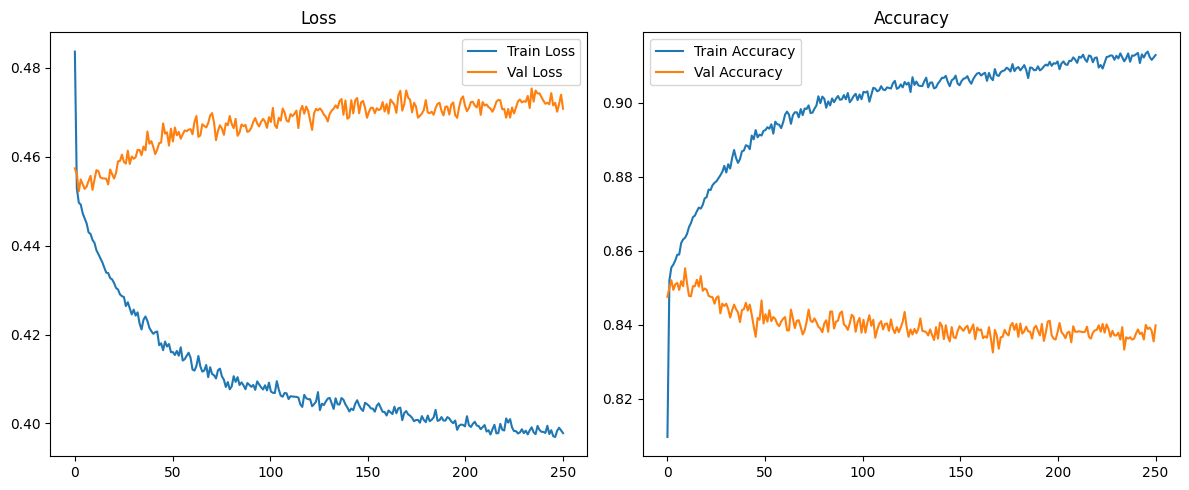

In [10]:
axis = np.linspace(0, len(history['train_loss']), len(history['train_loss']))

fig, ax = plt.subplots(1, 2, figsize = [12,5])
ax[0].plot(axis, history['train_loss'], label='Train Loss')
ax[0].plot(axis, history['val_loss'], label='Val Loss')
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(axis, history['train_acc'], label='Train Accuracy')
ax[1].plot(axis, history['val_acc'], label='Val Accuracy')
ax[1].set_title('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()